# TFM — Predicción del precio diario (D+1) con redes neuronales

Universidad Complutense de Madrid · Máster en Big Data y Data Science

**Problema.** A las 12:00 del día D, cuando cierra el mercado diario, hay que emitir de una vez
las **24 horas** de precio del día D+1. No es predicción a un paso: es una salida multi-horizonte
directa, y esa diferencia condiciona toda la arquitectura.

## Relación con los notebooks de clase

| Notebook de clase | Qué se reutiliza | Qué hay que cambiar |
|---|---|---|
| `Introduction_to_RNN_Time_Series` | Ventanas deslizantes, pipeline de series | Allí es *one-step-ahead* recursivo; aquí, salida directa de 24 valores |
| `IMBD_RNN` | LSTM apiladas, Deep RNN | Allí clasificación con `softmax`; aquí regresión con salida lineal |
| `Seq2seq` / `03_deep_learning_text_translation` | Encoder → `RepeatVector` → decoder → `TimeDistributed` | El decoder recibe **exógenas futuras concatenadas**, no solo el contexto repetido |
| `04-attention` | Base teórica para el capítulo de interpretabilidad | — |

## Tres cosas que los notebooks de clase hacen y aquí serían errores

1. **`Bidirectional` en el decoder.** En texto es gratis. En una serie temporal, una capa
   bidireccional sobre la ventana de salida mira horas futuras para predecir la actual. En el
   **encoder** sí vale: ese pasado ya ocurrió entero.
2. **`softmax` + `sparse_categorical_crossentropy`.** Esto es regresión: salida lineal y pérdida
   **Huber**. Con MSE, los picos de 2022 (>500 €/MWh) dominarían el gradiente y el modelo se
   dedicaría a esos días a costa de los 2.000 normales.
3. **Escalar antes de partir.** El notebook de Jena calcula media y desviación sobre el conjunto
   completo. Eso mete información de test en el preprocesado. Aquí el escalador **se ajusta solo
   con train**.

In [ ]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print("GPUs:", gpus)
for g in gpus:
    print(tf.config.experimental.get_device_details(g))

GPUs: []


In [ ]:
import warnings, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

SEMILLA = 42
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)

VENTANA_DIAS = 7          # encoder: 7 dias = 168 h, cubre el ciclo semanal completo
EPOCHS = 80
BATCH = 32

# Variante del bloque ntc_*_prev_mw. Los indicadores ESIOS 1844-1850 no arrancan hasta
# noviembre de 2020, asi que hay que elegir: quitar las columnas y conservar los dias, o
# conservarlas y descartar ~330 dias. Se generan las dos matrices y se comparan cambiando esta
# constante. Ejecuta el notebook entero con cada valor y compara EN VALIDACION.
VARIANTE = "sin_ntc_prev"          # "sin_ntc_prev" | "sin_2020"

# Encoder multicanal: precio + las series reales horarias como canales. False vuelve al
# encoder de un solo canal (solo precio) -- es la ablacion que cuantifica cuanto aporta.
ENCODER_MULTICANAL = True

# Apagon iberico del 28-abr-2025: no es una observacion extrema que el modelo deba aprender,
# es una observacion de OTRO proceso (cero de suministro, restricciones masivas, arranque
# escalonado). Se excluye el periodo y ademas las ventanas del encoder que lo pisen.
PERIODOS_EXCLUIDOS = [("2025-04-28", "2025-05-06")]

print("TensorFlow", tf.__version__, "| GPU:", bool(tf.config.list_physical_devices("GPU")))
print(f"variante: {VARIANTE} | encoder multicanal: {ENCODER_MULTICANAL}")

TensorFlow 2.21.0 | GPU: False
variante: sin_ntc_prev | encoder multicanal: True


## 1. Carga del dataset maestro horario

Una fila por `(día objetivo, hora)`. `fecha_pred` es el día **D** en que se emite la predicción;
`fecha_objetivo` es **D+1**, el día que se predice.

In [ ]:
CARPETA = Path(".")          # en Colab: CARPETA = CARPETA_DRIVE
candidatos = sorted(CARPETA.glob(f"dataset_horario*{VARIANTE}_v[0-9][0-9].csv"))
assert candidatos, (f"No encuentro dataset_horario_*{VARIANTE}_*.csv en {CARPETA}. "
                    f"Lanza antes construir_dataset_maestro_sergio.py")
RUTA = candidatos[-1]

df = pd.read_csv(RUTA, parse_dates=["fecha_pred", "fecha_objetivo"])
df = df.sort_values(["fecha_objetivo", "hora"]).reset_index(drop=True)

print(f"{RUTA.name}: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"rango: {df.fecha_objetivo.min().date()} -> {df.fecha_objetivo.max().date()}")
print(df.split.value_counts().to_string())

dataset_horario_sin_ntc_prev_v01.csv: 57,425 filas x 93 columnas
rango: 2020-01-03 -> 2026-07-31
split
train         43819
validation     8543
test           5063


In [ ]:
# Reparto por la FRONTERA DE FUGA (12:00 del dia D), no por el tipo de dato.
CLAVES = ["fecha_pred", "fecha_objetivo", "hora", "target_price", "split"]

# (a) DECODER -- publicado por adelantado y describe D+1, hora a hora
cols_dec = ([c for c in df.columns if c.endswith("_prev_mw")]
            + [c for c in df.columns if c.startswith("ree_ntc_")]
            + [c for c in df.columns if c == "es_esios_D"]
            + [c for c in df.columns if c in ("hora_sin", "hora_cos")])
cols_dec = list(dict.fromkeys(cols_dec))

# (b) ENCODER -- series reales horarias. `*_Dm1` de la fila con fecha_objetivo = T es el dato
#     del dia T-2, asi que reindexando por esa fecha se recupera la serie continua completa.
cols_dm1 = [c for c in df.columns if c.endswith("_Dm1") and c != "es_esios_Dm1"]

# (c) ESTATICOS -- constantes dentro del dia
cols_est = [c for c in df.columns
            if c.startswith(("pdbc_", "capinst_", "capdisp_", "d1_"))
            or c in ("gas_mibgas", "co2_eua_dec", "gas_ttf_m1")]
if ENCODER_MULTICANAL:
    # Las series reales viven en el ENCODER como canales. Dejarlas ademas agregadas aqui seria
    # escribir el mismo dato dos veces y con peor resolucion: la LSTM comparte pesos entre los
    # 168 pasos, asi que aprende UNA VEZ "como se comporta la eolica" y lo aplica a todas las
    # horas. En columnas planas, wind_D-1 y wind_D-7 son dos variables sin relacion, cada una
    # con su peso, y hay que aprender desde cero que son la misma magnitud.
    cols_est = [c for c in cols_est if not c.endswith(("_Dm1", "_Dm6"))]
else:
    cols_est += [c for c in df.columns if c.endswith(("_Dm1", "_Dm6"))]

const = [c for c in cols_dec + cols_est if df[c].nunique(dropna=True) <= 1]
cols_dec = [c for c in cols_dec if c not in const]
cols_est = [c for c in cols_est if c not in const]

print(f"descartadas por constantes ({len(const)}): {const}")
print(f"\ndecoder {len(cols_dec)} | encoder {len(cols_dm1)+1} canales | estaticos {len(cols_est)}")

descartadas por constantes (5): ['capinst_pump_mw', 'capinst_nuclear_mw', 'capinst_fuel_mw', 'capinst_ccgt_mw', 'capdisp_fuel_mw']

decoder 15 | encoder 22 canales | estaticos 47


## 2. De tabla larga a tensores — ventanas deslizantes

Es el patrón *Sliding Windows* del notebook de clase, adaptado a salida directa:

- **`X_enc` (n, 168, C)** — los 7 días previos hora a hora. Canal 0 el precio (ventana que
  termina en el día **D**, cuyo precio se casó ayer a las 12:00 y lleva 23 h publicado), y el
  resto las series reales de D−7 a D−1. El día D **no** entra en los canales reales: a las
  12:00 solo han ocurrido sus horas 00–11.
- **`X_dec` (n, 24, f)** — previsiones de D+1 hora a hora + precio de D alineado por hora.
- **`X_est` (n, j)** — lo que no varía dentro del día.
- **`y` (n, 24)** — el target.

**Por qué canales y no columnas con lag.** Con 17 tecnologías × 3 estadísticos × 7 días serían
357 columnas, y además `wind_D-1` y `wind_D-7` serían para el modelo dos variables sin relación
alguna. La LSTM **comparte los mismos pesos en los 168 pasos**: aprende una vez cómo se comporta
la eólica y lo aplica a todas las horas. Pasar de 1 a 21 canales apenas mueve el número de
parámetros.

**Contigüidad.** Al excluir el apagón se abre un hueco en la serie, y `PRECIO[t-V:t]` opera
sobre los días *disponibles*. Sin comprobarlo, la fila posterior al hueco tomaría siete jornadas
no consecutivas: entrenaría igual, sin avisar, y solo se notaría en un rendimiento algo peor.

In [ ]:
dias = np.array(sorted(df.fecha_objetivo.unique()))
n_dias = len(dias)

def panel(cols):
    "(fecha_objetivo, hora) -> (n_dias, 24, len(cols))"
    p = (df.pivot_table(index="fecha_objetivo", columns="hora", values=cols, aggfunc="mean")
           .reindex(dias))
    return np.stack([p[c].to_numpy(dtype="float32") for c in cols], axis=-1)

PRECIO = (df.pivot_table(index="fecha_objetivo", columns="hora", values="target_price",
                         aggfunc="mean").reindex(dias).to_numpy(dtype="float32"))
DEC = panel(cols_dec)
EST = (df.groupby("fecha_objetivo")[cols_est].first().reindex(dias).to_numpy(dtype="float32"))

# series reales -> canales del encoder (ver nota de la celda anterior)
canales = ["precio"]
REAL = None
if ENCODER_MULTICANAL and cols_dm1:
    h = df[["fecha_objetivo", "hora"] + cols_dm1].copy()
    h["fecha_objetivo"] = h["fecha_objetivo"] - pd.Timedelta(days=2)   # _Dm1 de T -> dia T-2
    nm = [c[:-4] for c in cols_dm1]
    h = h.rename(columns=dict(zip(cols_dm1, nm)))
    pv = (h.pivot_table(index="fecha_objetivo", columns="hora", values=nm, aggfunc="mean")
            .reindex(dias))
    REAL = np.stack([pv[c].to_numpy(dtype="float32") for c in nm], axis=-1)
    canales += nm

V = VENTANA_DIAS
t_idx = np.arange(V + 1, n_dias)

# ventanas que pisan un periodo anomalo o que no son contiguas
dias_dt = pd.to_datetime(dias)
excl = np.zeros(n_dias, dtype=bool)
for ini, fin in PERIODOS_EXCLUIDOS:
    excl |= (dias_dt >= ini) & (dias_dt <= fin)
ok_v = np.array([(not excl[t - V - 1:t].any())
                 and (dias_dt[t - 1] - dias_dt[t - V - 1]).days == V
                 for t in t_idx])
print(f"{int((~ok_v).sum())} dias descartados por periodo anomalo o ventana no contigua")
t_idx = t_idx[ok_v]

X_enc = np.stack([
    np.concatenate([PRECIO[t - V:t].reshape(24 * V, 1)]        # precio: hasta el dia D
                   + ([REAL[t - V - 1:t - 1].reshape(24 * V, REAL.shape[-1])]  # reales: hasta D-1
                      if REAL is not None else []), axis=-1)
    for t in t_idx])
X_dec, X_est, y = DEC[t_idx], EST[t_idx], PRECIO[t_idx]
fechas = dias[t_idx]

print(f"X_enc {X_enc.shape} | X_dec {X_dec.shape} | X_est {X_est.shape} | y {y.shape}")
print(f"canales del encoder ({len(canales)}): {canales}")
print(f"primer dia predicho: {pd.Timestamp(fechas[0]).date()}")

7 dias descartados por periodo anomalo o ventana no contigua
X_enc (2378, 168, 22) | X_dec (2378, 24, 15) | X_est (2378, 47) | y (2378, 24)
canales del encoder (22): ['precio', 'ree_load', 'entsoe_load', 'ree_netflow_fr', 'ree_netflow_pt', 'ree_netflow_ma', 'total_net_flow_mw', 'gen_peninsular_mw', 'wind_mw', 'pumping_cons_mw', 'hydro_run_river_mw', 'biomass_mw', 'waste_mw', 'other_renewable_mw', 'oil_mw', 'ree_gsolter_mw', 'ree_gccgas_mw', 'ree_gbattery_mw', 'ree_cbattery_mw', 'ree_gnuclear_mw', 'ree_gotherthermal_mw', 'ree_gcoal_mw']
primer dia predicho: 2020-01-11


In [ ]:
# Un solo NaN en X hace que la perdida salga `nan` desde la primera epoca, SIN lanzar ningun
# error. Es el fallo mas dificil de diagnosticar en Keras: se comprueba antes de entrenar.
for n, a in [("X_enc", X_enc), ("X_dec", X_dec), ("X_est", X_est), ("y", y)]:
    k = int(np.isnan(a).sum())
    print(f"{n:<6} NaN: {k:>7,}  ({100*k/a.size:.3f}%)")

X_dec = np.nan_to_num(X_dec)
X_est = np.nan_to_num(X_est)
ok = ~np.isnan(y).any(axis=1) & ~np.isnan(X_enc).any(axis=(1, 2))
X_enc, X_dec, X_est, y, fechas = X_enc[ok], X_dec[ok], X_est[ok], y[ok], fechas[ok]
print(f"\nfilas utiles: {ok.sum()} de {len(ok)}")

X_enc  NaN:   2,562  (0.029%)
X_dec  NaN:     135  (0.016%)
X_est  NaN:     334  (0.299%)
y      NaN:       7  (0.012%)

filas utiles: 2307 de 2378


## 3. Split cronológico, purga de columnas y escalado

**El split se corta por día, jamás por fila.** Las 24 horas de un día comparten conjunto de
información; un `train_test_split(shuffle=True)` pondría horas del mismo día a ambos lados y el
modelo "acertaría" copiando de sus vecinas.

**Purga de columnas sin varianza EN TRAIN.** El filtro de constantes de la §1 mira todo el
rango, y eso deja pasar un caso letal: una columna puede ser constante *solo dentro de train* y
variar después. Los indicadores de batería (ESIOS 2166/2167) publican desde el 20-nov-2024 y
train acaba el 31-dic-2024, así que en train valen 0 y en test valen cientos de MW. Al
estandarizar, su desviación de train es 0, se divide entre el epsilon y **todo val/test se
multiplica por un millón**. En la primera ejecución esto produjo `val_loss` de 268.000 y un MAE
de 832.039 €/MWh con la pérdida de entrenamiento en 0,02 — el patrón que delata que el problema
está en el preprocesado y no en el modelo.

**El escalador se ajusta solo con train.** Es la fuga más silenciosa que existe: usar la media
del conjunto completo mete información de test en el preprocesado.

In [ ]:
f = pd.to_datetime(fechas)
tr = f <= "2024-12-31"
va = (f > "2024-12-31") & (f <= "2025-12-31")
te = f > "2025-12-31"
print(f"train {tr.sum()} | val {va.sum()} | test {te.sum()} dias\n")

def purgar(X, nombres, etiqueta):
    "Descarta columnas cuya desviacion en TRAIN es cero (ver nota de la celda anterior)."
    ejes = tuple(range(X.ndim - 1))
    sd = X[tr].std(axis=ejes)
    malas = set(np.where(sd < 1e-8)[0].tolist())
    if malas:
        print(f"[{etiqueta}] {len(malas)} columnas sin varianza en train, descartadas:")
        print("   " + ", ".join(nombres[i] for i in sorted(malas)))
    buenas = [i for i in range(X.shape[-1]) if i not in malas]
    return X[..., buenas], [nombres[i] for i in buenas]

X_dec, cols_dec = purgar(X_dec, cols_dec, "decoder")
X_est, cols_est = purgar(X_est, cols_est, "estaticos")
i_pD = cols_dec.index("es_esios_D")        # el indice se ha desplazado: recalcular

class Escalador:
    def fit(self, x):
        ejes = tuple(range(x.ndim - 1))
        self.mu = x.mean(axis=ejes, keepdims=True)
        sd = x.std(axis=ejes, keepdims=True)
        self.sd = np.where(sd < 1e-8, 1.0, sd)      # nunca dividir por ~0
        return self
    def __call__(self, x):
        # clip a 10 sigmas: un valor mas extremo es cambio de regimen o outlier, y en ningun
        # caso debe dominar el gradiente
        return np.clip((x - self.mu) / self.sd, -10, 10).astype("float32")

s_enc = Escalador().fit(X_enc[tr]); s_dec = Escalador().fit(X_dec[tr]); s_est = Escalador().fit(X_est[tr])
mu_y, sd_y = float(y[tr].mean()), float(y[tr].std())   # un solo mu/sd: las 24 salidas
                                                       # comparten unidad (EUR/MWh)
Xe, Xd, Xs = s_enc(X_enc), s_dec(X_dec), s_est(X_est)
ys = ((y - mu_y) / sd_y).astype("float32")
inv = lambda p: p * sd_y + mu_y

# VERIFICACION -- sin esto, un fallo de escalado vuelve a pasar desapercibido
print("\ncomprobacion de escalado (|max| debe quedar bajo el clip, medias de train cerca de 0)")
for n, a in [("Xe", Xe), ("Xd", Xd), ("Xs", Xs)]:
    for m, nm in [(tr, "train"), (va, "val"), (te, "test")]:
        print(f"  {n} {nm:<6} |max| {np.abs(a[m]).max():7.2f}   media {a[m].mean():+6.3f}")
print(f"\nprecio train: media {mu_y:.1f}  sd {sd_y:.1f} EUR/MWh")

train 1765 | val 339 | test 203 dias

[estaticos] 1 columnas sin varianza en train, descartadas:
   d1_regimen_autoconsumo

comprobacion de escalado (|max| debe quedar bajo el clip, medias de train cerca de 0)
  Xe train  |max|   10.00   media +0.000
  Xe val    |max|   10.00   media -0.375
  Xe test   |max|   10.00   media -0.407
  Xd train  |max|    8.69   media -0.000
  Xd val    |max|    6.21   media +0.028
  Xd test   |max|    6.15   media +0.196
  Xs train  |max|   10.00   media +0.003
  Xs val    |max|   10.00   media +0.431
  Xs test   |max|   10.00   media +0.876

precio train: media 93.8  sd 69.7 EUR/MWh


## 4. Baselines — obligatorios y primeros

El precio eléctrico tiene una autocorrelación enorme: repetir el precio de ayer ya acierta
bastante. Un MAE de 8 €/MWh no significa nada por sí solo; significa algo **comparado con el
naive**. Sin esta referencia el capítulo no tiene contra qué medirse.

Sirven además de detector de fugas: si una red baja mucho del naive, lo probable no es que sea
brillante sino que se ha colado información posterior al cierre del mercado.

In [ ]:
def metricas(yt, yp):
    e = yp - yt
    den = (np.abs(yt) + np.abs(yp)) / 2          # sMAPE, no MAPE: el precio pasa por cero
    n = np.arange(len(yt))
    # captura de spread: que fraccion del arbitraje perfecto se obtiene cargando en la hora de
    # valle PREDICHA y descargando en la de pico PREDICHA. El MAE mide precision de precio;
    # esto mide valor economico, y no son lo mismo -- un modelo con peor MAE que clave las
    # horas vale mas para operar una bateria que uno preciso que las confunda.
    cap = ((yt[n, yp.argmax(1)] - yt[n, yp.argmin(1)]) /
           np.maximum(yt.max(1) - yt.min(1), .1))
    return {"MAE": float(np.abs(e).mean()),
            "RMSE": float(np.sqrt((e ** 2).mean())),
            "sMAPE": float(100 * np.mean(np.abs(e) / np.maximum(den, 1e-3))),
            "captura_%": float(100 * cap.mean()),
            "pico_1h_%": float(100 * (np.abs(yt.argmax(1) - yp.argmax(1)) <= 1).mean())}

res, preds = {}, {}
i_pD = cols_dec.index("es_esios_D")
res["naive D (precio de hoy)"] = metricas(y[te], X_dec[te][:, :, i_pD])

y_sem = np.stack([y[max(i - 7, 0)] for i in np.where(te)[0]])
res["naive D-6 (misma semana)"] = metricas(y[te], y_sem)

pd.DataFrame(res).T.round(2)

,MAE,RMSE,sMAPE,captura_%,pico_1h_%
naive D (precio de hoy),17.19,26.03,72.44,86.30,67.49
naive D-6 (misma semana),26.47,38.45,88.52,85.37,72.41


## 5. Modelo 1 — MLP multi-salida

El punto de partida: aplanar todo y una red densa. Sin recurrencia, pero es un competidor serio
y establece si la estructura temporal aporta algo o no.

Frente a `First_Model` de clase, cambia solo el final: `Dense(24)` **lineal** en lugar de
`softmax`, y `Huber` en lugar de crossentropy.

In [ ]:
plano = np.concatenate([Xe.reshape(len(Xe), -1), Xd.reshape(len(Xd), -1), Xs], axis=1)
print("matriz plana:", plano.shape)

def compilar(m, lr=1e-3):
    m.compile(optimizer=keras.optimizers.Adam(lr),
              loss=keras.losses.Huber(delta=1.0), metrics=["mae"])
    return m

CB = lambda: [keras.callbacks.EarlyStopping(monitor="val_loss", patience=12,
                                            restore_best_weights=True),
              keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5,
                                                min_lr=1e-5)]

mlp = compilar(keras.Sequential([
    layers.Input(shape=(plano.shape[1],)),
    layers.Dense(512, activation="relu"), layers.Dropout(0.2),
    layers.Dense(256, activation="relu"), layers.Dropout(0.2),
    layers.Dense(24),                       # LINEAL: es regresion
], name="MLP"))
mlp.summary()

h_mlp = mlp.fit(plano[tr], ys[tr], validation_data=(plano[va], ys[va]),
                epochs=EPOCHS, batch_size=BATCH, callbacks=CB(), verbose=2)
preds["MLP"] = inv(mlp.predict(plano[te], verbose=0))
res["MLP"] = metricas(y[te], preds["MLP"])
res["MLP"]

matriz plana: (2307, 4102)


Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 512)            │     2,100,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,238,232 (8.54 MB)

 Trainable params: 2,238,232 (8.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
56/56 - 1s - 19ms/step - loss: 0.2556 - mae: 0.5614 - val_loss: 0.2228 - val_mae: 0.5421 - learning_rate: 0.0010
Epoch 2/80
56/56 - 1s - 9ms/step - loss: 0.1217 - mae: 0.3704 - val_loss: 0.3596 - val_mae: 0.7142 - learning_rate: 0.0010
Epoch 3/80
56/56 - 1s - 9ms/step - loss: 0.0983 - mae: 0.3291 - val_loss: 0.2745 - val_mae: 0.6193 - learning_rate: 0.0010
Epoch 4/80
56/56 - 1s - 9ms/step - loss: 0.0813 - mae: 0.2991 - val_loss: 0.2562 - val_mae: 0.5823 - learning_rate: 0.0010
Epoch 5/80
56/56 - 0s - 9ms/step - loss: 0.0856 - mae: 0.3027 - val_loss: 0.3267 - val_mae: 0.6714 - learning_rate: 0.0010
Epoch 6/80
56/56 - 1s - 9ms/step - loss: 0.0725 - mae: 0.2776 - val_loss: 0.1765 - val_mae: 0.5036 - learning_rate: 0.0010
Epoch 7/80
56/56 - 1s - 9ms/step - loss: 0.0682 - mae: 0.2680 - val_loss: 0.2583 - val_mae: 0.5823 - learning_rate: 0.0010
Epoch 8/80
56/56 - 0s - 9ms/step - loss: 0.0672 - mae: 0.2686 - val_loss: 0.2140 - val_mae: 0.5301 - learning_rate: 0.0010
Epoch 9/80
56/5

{'MAE': 32.57951354980469,
 'RMSE': 39.975189208984375,
 'sMAPE': 85.35900115966797,
 'captura_%': 79.65970611572266,
 'pico_1h_%': 66.99507389162561}

## 6. Modelo 2 — LSTM apilada sobre el histórico

Patrón *Deep RNN* de `IMBD_RNN`: dos LSTM encadenadas, la primera con `return_sequences=True`.
El encoder digiere las 168 horas de precio y su salida se concatena con las exógenas aplanadas.

`Bidirectional` **sí** aquí: el encoder solo ve pasado ya ocurrido.

In [ ]:
in_e = keras.Input(shape=Xe.shape[1:], name="hist")
in_d = keras.Input(shape=Xd.shape[1:], name="fut")
in_s = keras.Input(shape=(Xs.shape[1],), name="est")

x = layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.2))(in_e)
x = layers.Bidirectional(layers.LSTM(64, dropout=0.2))(x)
x = layers.Concatenate()([x, layers.Flatten()(in_d), in_s])
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
out = layers.Dense(24)(x)

lstm = compilar(keras.Model([in_e, in_d, in_s], out, name="LSTM_apilada"))
lstm.summary()

ent = lambda m: {"hist": Xe[m], "fut": Xd[m], "est": Xs[m]}
h_lstm = lstm.fit(ent(tr), ys[tr], validation_data=(ent(va), ys[va]),
                  epochs=EPOCHS, batch_size=BATCH, callbacks=CB(), verbose=2)
preds["LSTM apilada"] = inv(lstm.predict(ent(te), verbose=0))
res["LSTM apilada"] = metricas(y[te], preds["LSTM apilada"])
res["LSTM apilada"]

Model: "LSTM_apilada"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ hist (InputLayer)   │ (None, 168, 22)   │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 168, 128)  │     44,544 │ hist[0][0]        │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fut (InputLayer)    │ (None, 24, 15)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 128)       │     98,816 │ bidirectional_2[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 360)       │          0 │ fut[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ est (InputLayer)    │ (None, 46)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 534)       │          0 │ bidirectional_3[… │
│ (Concatenate)       │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ est[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 128)       │     68,480 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128)       │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 24)        │      3,096 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 214,936 (839.59 KB)

 Trainable params: 214,936 (839.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
56/56 - 7s - 118ms/step - loss: 0.1949 - mae: 0.4791 - val_loss: 0.1844 - val_mae: 0.4926 - learning_rate: 0.0010
Epoch 2/80
56/56 - 3s - 61ms/step - loss: 0.0872 - mae: 0.3110 - val_loss: 0.1987 - val_mae: 0.5156 - learning_rate: 0.0010
Epoch 3/80
56/56 - 3s - 58ms/step - loss: 0.0753 - mae: 0.2858 - val_loss: 0.2259 - val_mae: 0.5611 - learning_rate: 0.0010
Epoch 4/80
56/56 - 4s - 72ms/step - loss: 0.0637 - mae: 0.2650 - val_loss: 0.1409 - val_mae: 0.4251 - learning_rate: 0.0010
Epoch 5/80
56/56 - 4s - 70ms/step - loss: 0.0574 - mae: 0.2490 - val_loss: 0.1555 - val_mae: 0.4449 - learning_rate: 0.0010
Epoch 6/80
56/56 - 4s - 71ms/step - loss: 0.0559 - mae: 0.2433 - val_loss: 0.1885 - val_mae: 0.5015 - learning_rate: 0.0010
Epoch 7/80
56/56 - 4s - 74ms/step - loss: 0.0517 - mae: 0.2363 - val_loss: 0.1446 - val_mae: 0.4355 - learning_rate: 0.0010
Epoch 8/80
56/56 - 4s - 69ms/step - loss: 0.0481 - mae: 0.2279 - val_loss: 0.1506 - val_mae: 0.4486 - learning_rate: 0.0010
Epoch 9

{'MAE': 34.684844970703125,
 'RMSE': 43.540245056152344,
 'sMAPE': 86.39321899414062,
 'captura_%': 84.84893798828125,
 'pico_1h_%': 70.93596059113301}

## 7. Modelo 3 — Seq2Seq encoder-decoder

La arquitectura que encaja con la estructura del problema, y el aporte propio del trabajo.

El esqueleto viene de `Seq2seq` y del notebook de traducción:
`LSTM → RepeatVector → LSTM(return_sequences=True) → TimeDistributed(Dense)`.

**Con una modificación decisiva.** En traducción, `RepeatVector` repite el contexto porque no hay
nada específico de cada paso de salida. Aquí sí lo hay: se conoce la previsión solar *de las
14:00*, la eólica *de las 03:00*, la NTC *de cada hora*. Por eso el contexto repetido se
**concatena** con `X_dec` antes del decoder, en lugar de entrar solo.

Esa concatenación es lo que justifica la arquitectura frente a un modelo tabular, y es
precisamente lo que ningún notebook de clase muestra: en traducción no existe un exógeno futuro
conocido.

El decoder es **unidireccional**, sin excepción.

In [ ]:
in_e = keras.Input(shape=Xe.shape[1:], name="hist")
in_d = keras.Input(shape=Xd.shape[1:], name="fut")
in_s = keras.Input(shape=(Xs.shape[1],), name="est")

# ENCODER: bidireccional (pasado completo, sin fuga)
enc = layers.Bidirectional(layers.LSTM(128, dropout=0.2), name="encoder")(in_e)
ctx = layers.Concatenate(name="contexto")([enc, layers.Dense(64, activation="relu")(in_s)])

# el contexto repetido 24 veces SE CONCATENA con la prevision horaria de D+1
ctx_rep = layers.RepeatVector(24)(ctx)
dec_in = layers.Concatenate(name="contexto_mas_prevision")([ctx_rep, in_d])

# DECODER: unidireccional obligatorio
dec = layers.LSTM(128, return_sequences=True, dropout=0.2, name="decoder")(dec_in)
dec = layers.Dropout(0.2)(dec)
out = layers.Reshape((24,))(layers.TimeDistributed(layers.Dense(1))(dec))

s2s = compilar(keras.Model([in_e, in_d, in_s], out, name="Seq2Seq"))
s2s.summary()

h_s2s = s2s.fit(ent(tr), ys[tr], validation_data=(ent(va), ys[va]),
                epochs=EPOCHS, batch_size=BATCH, callbacks=CB(), verbose=2)
preds["Seq2Seq"] = inv(s2s.predict(ent(te), verbose=0))
res["Seq2Seq"] = metricas(y[te], preds["Seq2Seq"])
res["Seq2Seq"]

Model: "Seq2Seq"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ hist (InputLayer)   │ (None, 168, 22)   │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ est (InputLayer)    │ (None, 46)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder             │ (None, 256)       │    154,624 │ hist[0][0]        │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 64)        │      3,008 │ est[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ contexto            │ (None, 320)       │          0 │ encoder[0][0],    │
│ (Concatenate)       │                   │            │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 24, 320)   │          0 │ contexto[0][0]    │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fut (InputLayer)    │ (None, 24, 15)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ contexto_mas_previ… │ (None, 24, 335)   │          0 │ repeat_vector[0]… │
│ (Concatenate)       │                   │            │ fut[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder (LSTM)      │ (None, 24, 128)   │    237,568 │ contexto_mas_pre… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 24, 128)   │          0 │ decoder[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 24, 1)     │        129 │ dropout_6[0][0]   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 24)        │          0 │ time_distributed… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 395,329 (1.51 MB)

 Trainable params: 395,329 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
56/56 - 8s - 136ms/step - loss: 0.1271 - mae: 0.3771 - val_loss: 0.0731 - val_mae: 0.3142 - learning_rate: 0.0010
Epoch 2/80
56/56 - 3s - 62ms/step - loss: 0.0719 - mae: 0.2762 - val_loss: 0.0891 - val_mae: 0.3501 - learning_rate: 0.0010
Epoch 3/80
56/56 - 3s - 62ms/step - loss: 0.0629 - mae: 0.2574 - val_loss: 0.0885 - val_mae: 0.3489 - learning_rate: 0.0010
Epoch 4/80
56/56 - 3s - 61ms/step - loss: 0.0545 - mae: 0.2389 - val_loss: 0.0937 - val_mae: 0.3605 - learning_rate: 0.0010
Epoch 5/80
56/56 - 4s - 65ms/step - loss: 0.0520 - mae: 0.2300 - val_loss: 0.1218 - val_mae: 0.4199 - learning_rate: 0.0010
Epoch 6/80
56/56 - 4s - 66ms/step - loss: 0.0486 - mae: 0.2196 - val_loss: 0.1348 - val_mae: 0.4462 - learning_rate: 0.0010
Epoch 7/80
56/56 - 4s - 66ms/step - loss: 0.0477 - mae: 0.2174 - val_loss: 0.1206 - val_mae: 0.4135 - learning_rate: 5.0000e-04
Epoch 8/80
56/56 - 4s - 65ms/step - loss: 0.0442 - mae: 0.2104 - val_loss: 0.1198 - val_mae: 0.4112 - learning_rate: 5.0000e-04

{'MAE': 26.82067108154297,
 'RMSE': 32.83067321777344,
 'sMAPE': 81.922607421875,
 'captura_%': 83.23076629638672,
 'pico_1h_%': 56.15763546798029}

## 8. Comparativa y análisis del error

In [ ]:
tabla = pd.DataFrame(res).T.sort_values("MAE")
base = tabla.loc[[i for i in tabla.index if i.startswith("naive")], "MAE"].min()
tabla["vs_naive_%"] = (100 * (tabla["MAE"] / base - 1)).round(1)
display(tabla.round(2))

mejor = tabla.index[0]
print(f"\nMejor modelo: {mejor}")
if tabla.loc[mejor, "MAE"] < 3:
    print("*** MAE sospechosamente bajo: antes de darlo por bueno, revisa si algun canal de")
    print("    X_dec contiene informacion posterior al cierre del mercado. ***")

,MAE,RMSE,sMAPE,captura_%,pico_1h_%,vs_naive_%
naive D (precio de hoy),17.19,26.03,72.44,86.30,67.49,0.0
naive D-6 (misma semana),26.47,38.45,88.52,85.37,72.41,54.0
Seq2Seq,26.82,32.83,81.92,83.23,56.16,56.0
MLP,32.58,39.98,85.36,79.66,67.00,89.5
LSTM apilada,34.68,43.54,86.39,84.85,70.94,101.8



Mejor modelo: naive D (precio de hoy)


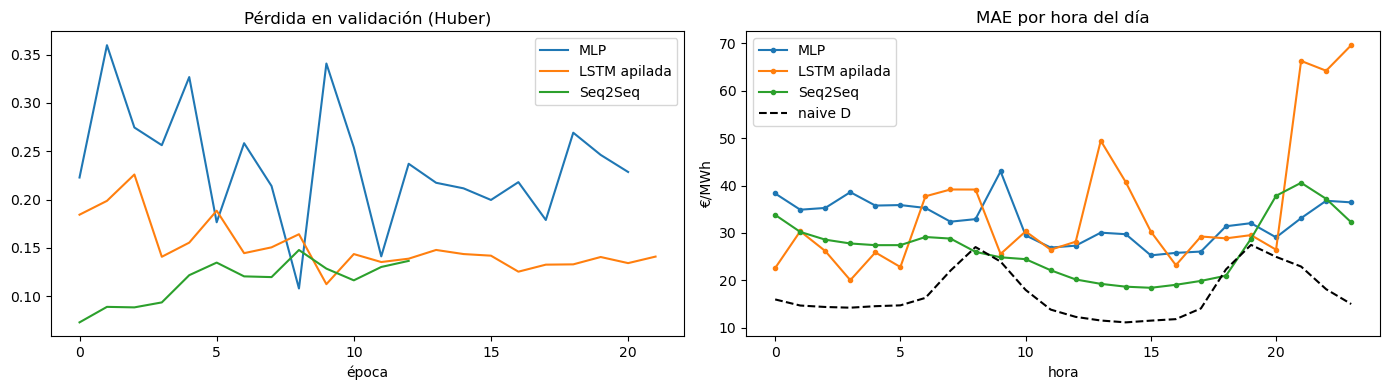

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

for k, h in [("MLP", h_mlp), ("LSTM apilada", h_lstm), ("Seq2Seq", h_s2s)]:
    ax[0].plot(h.history["val_loss"], label=k)
ax[0].set_title("Pérdida en validación (Huber)"); ax[0].set_xlabel("época"); ax[0].legend()

for k in preds:
    ax[1].plot(np.abs(preds[k] - y[te]).mean(axis=0), marker="o", ms=3, label=k)
ax[1].plot(np.abs(X_dec[te][:, :, i_pD] - y[te]).mean(axis=0), "k--", label="naive D")
ax[1].set_title("MAE por hora del día"); ax[1].set_xlabel("hora"); ax[1].set_ylabel("€/MWh")
ax[1].legend(); plt.tight_layout(); plt.show()

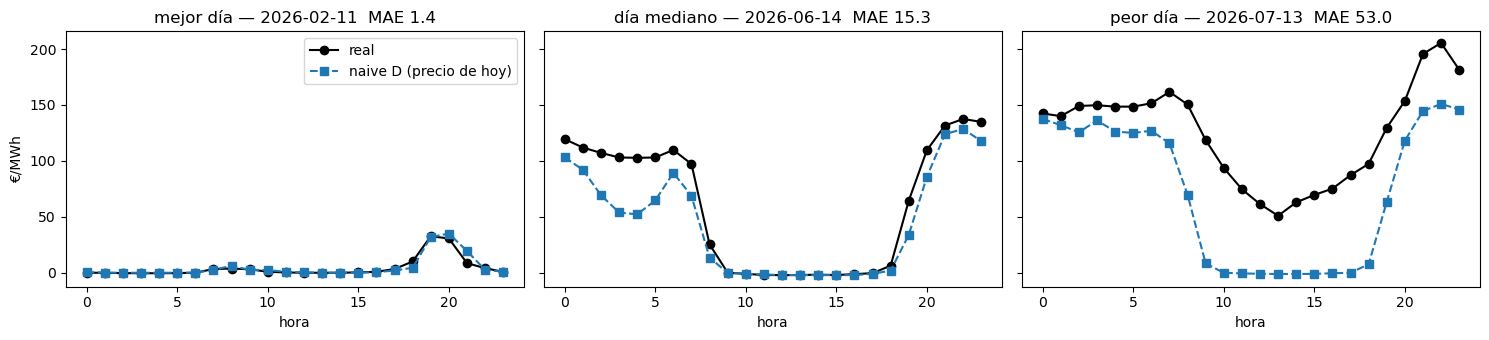

In [ ]:
# Los baselines tambien son predicciones: si el mejor resulta ser uno de ellos, tiene que poder
# graficarse igual que las redes (esto provocaba un KeyError en la version anterior).
preds["naive D (precio de hoy)"] = X_dec[te][:, :, i_pD]
preds["naive D-6 (misma semana)"] = y_sem

err_dia = np.abs(preds[mejor] - y[te]).mean(axis=1)
orden = np.argsort(err_dia)
sel = [int(orden[0]), int(orden[len(orden) // 2]), int(orden[-1])]
titulos = ["mejor día", "día mediano", "peor día"]

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5), sharey=True)
for a, i, t in zip(axes, sel, titulos):
    a.plot(y[te][i], "o-", color="black", label="real")
    a.plot(preds[mejor][i], "s--", label=mejor)
    a.set_title(f"{t} — {pd.Timestamp(fechas[te][i]).date()}  MAE {err_dia[i]:.1f}")
    a.set_xlabel("hora")
axes[0].set_ylabel("€/MWh"); axes[0].legend(); plt.tight_layout(); plt.show()

## 8b. Diagnóstico visual de un modelo

Los gráficos aquí no son adorno: son el diagnóstico. Con un MAE alto, la curva dice en dos
segundos si el modelo predice plano, si va sesgado en nivel o si solo falla en ciertas horas —
y cada caso tiene un remedio distinto.

**Cómo leer cada panel**

- **Dispersión.** El más informativo. Diagonal ancha = funciona, solo hay ruido. Nube *aplanada
  en horizontal* (predice ~90 tanto si el real es 20 como si es 200) = el modelo ha colapsado a
  la media del train.
- **Histograma del error.** Centrado en cero es ruido; desplazado es sesgo de nivel, y el
  remedio es la §8c.
- **MAE por hora.** Si pierde contra el naive solo en las horas de rampa solar (8–10, 18–20) es
  un problema de *forma*; si pierde en todas por igual, es de *nivel*.
- **Peor día.** Mira si acierta al menos la forma aunque falle la escala. Una línea plana
  significa que no ha aprendido nada.

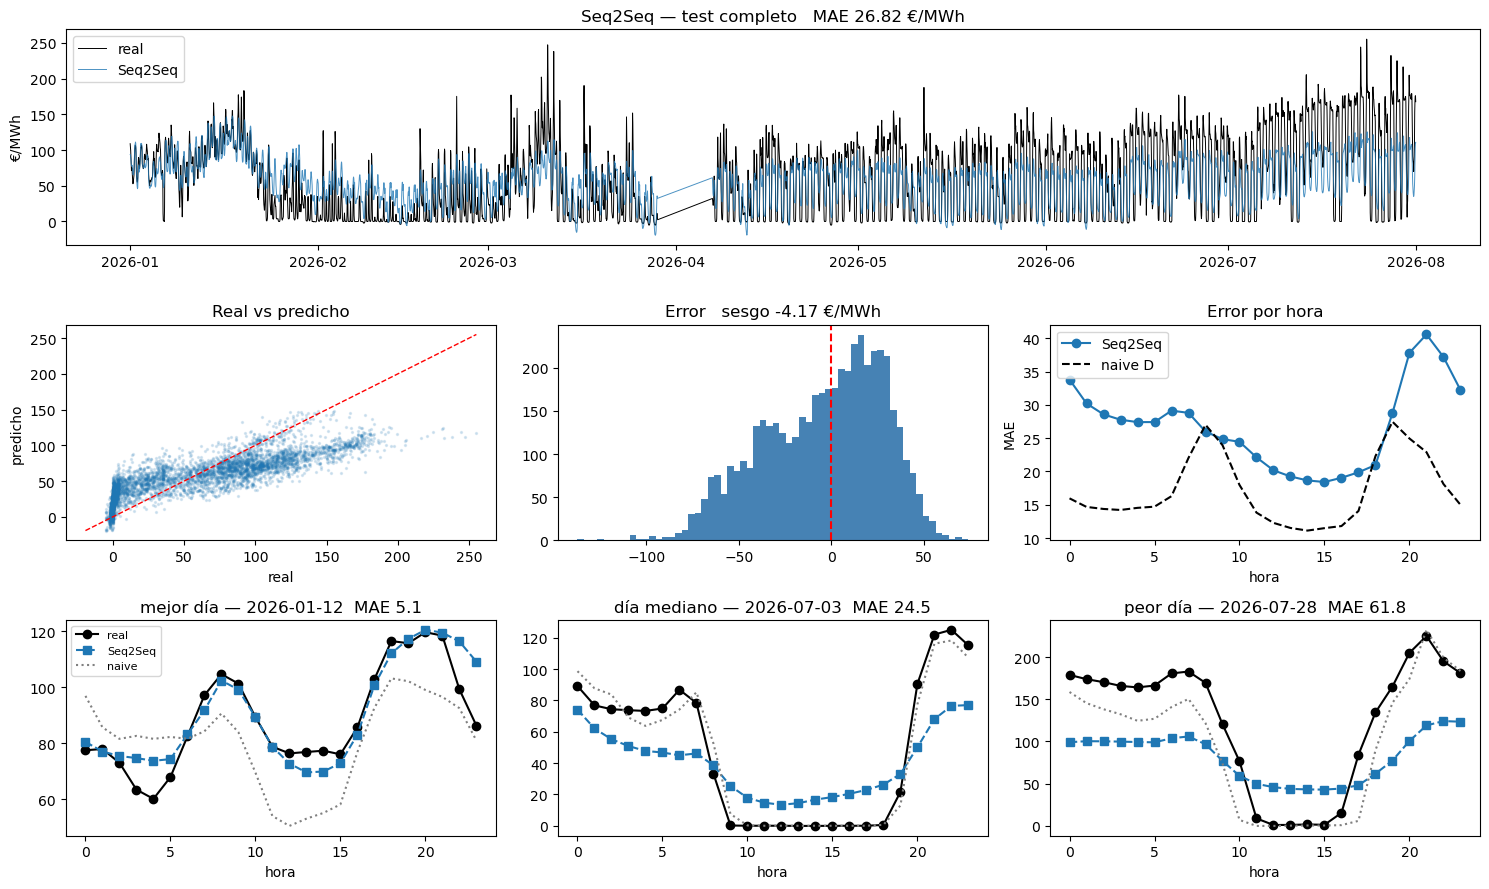

In [ ]:
MODELO = "Seq2Seq"          # cambia aqui el modelo a inspeccionar
MASCARA, NOMBRE_M = te, "test"   # durante la iteracion usa `va`; ver nota de la seccion 9

p, yt = preds[MODELO], y[MASCARA]
fm = pd.to_datetime(fechas[MASCARA])
ts = np.repeat(fm, 24) + pd.to_timedelta(np.tile(np.arange(24), len(fm)), "h")
err = p - yt

fig = plt.figure(figsize=(15, 9))

ax = fig.add_subplot(3, 1, 1)
ax.plot(ts, yt.ravel(), lw=.7, color="black", label="real")
ax.plot(ts, p.ravel(), lw=.7, alpha=.8, label=MODELO)
ax.set_title(f"{MODELO} — {NOMBRE_M} completo   MAE {np.abs(err).mean():.2f} €/MWh")
ax.set_ylabel("€/MWh"); ax.legend()

ax = fig.add_subplot(3, 3, 4)
ax.scatter(yt.ravel(), p.ravel(), s=2, alpha=.15)
lim = [float(min(yt.min(), p.min())), float(max(yt.max(), p.max()))]
ax.plot(lim, lim, "r--", lw=1)
ax.set_xlabel("real"); ax.set_ylabel("predicho"); ax.set_title("Real vs predicho")

ax = fig.add_subplot(3, 3, 5)
ax.hist(err.ravel(), bins=60, color="steelblue")
ax.axvline(0, color="r", ls="--")
ax.set_title(f"Error   sesgo {err.mean():+.2f} €/MWh")

ax = fig.add_subplot(3, 3, 6)
ax.plot(np.abs(err).mean(axis=0), "o-", label=MODELO)
ax.plot(np.abs(X_dec[MASCARA][:, :, i_pD] - yt).mean(axis=0), "k--", label="naive D")
ax.set_xlabel("hora"); ax.set_ylabel("MAE"); ax.set_title("Error por hora"); ax.legend()

e_dia = np.abs(err).mean(axis=1); orden = np.argsort(e_dia)
for k, (i, t) in enumerate(zip([orden[0], orden[len(orden)//2], orden[-1]],
                               ["mejor día", "día mediano", "peor día"])):
    ax = fig.add_subplot(3, 3, 7 + k)
    ax.plot(yt[i], "o-", color="black", label="real")
    ax.plot(p[i], "s--", label=MODELO)
    ax.plot(X_dec[MASCARA][i, :, i_pD], ":", color="grey", label="naive")
    ax.set_title(f"{t} — {fm[i].date()}  MAE {e_dia[i]:.1f}")
    ax.set_xlabel("hora")
    if k == 0: ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

## 8c. Variante: predecir el residuo frente al naive

Si el histograma de la §8b sale desplazado, el modelo ha aprendido el **nivel** de precios del
entrenamiento y lo arrastra. Es esperable: train incluye la crisis del gas de 2022 (media de 93
€/MWh) y el test es 2026, con niveles muy distintos. Una red regularizada tira hacia la media
del target que ha visto; el naive es inmune porque no aprende ningún nivel, solo copia.

**El remedio es cambiar el target, no la arquitectura.** En vez de aprender cuánto vale el
precio de mañana, la red aprende *cuánto se desvía respecto a hoy*. El target se vuelve
estacionario, el cambio de régimen deja de importar, y de regalo el modelo parte empatando al
naive: solo tiene que mejorarlo.

Compara el `sd` del residuo con el del precio: ahí se ve la ganancia. El modelo deja de tener
que reproducir un rango de 0 a 500 y solo modela un margen estrecho.

In [ ]:
naive_todos = X_dec[:, :, i_pD]                  # precio de D por hora, escala original
resid = y - naive_todos
mu_r, sd_r = float(resid[tr].mean()), float(resid[tr].std())
yr = ((resid - mu_r) / sd_r).astype("float32")
inv_r = lambda p, m: p * sd_r + mu_r + naive_todos[m]

print(f"residuo train: media {mu_r:+.2f}  sd {sd_r:.2f} EUR/MWh")
print(f"precio  train: media {mu_y:+.2f}  sd {sd_y:.2f} EUR/MWh   <- cuanto menor el sd del")
print("                                                              residuo, mas facil el problema")

def seq2seq(u=96, dr=0.3):
    "Misma arquitectura de la seccion 7, con menos capacidad: 1.778 dias no dan para 128 unidades."
    ie = keras.Input(shape=Xe.shape[1:], name="hist")
    idc = keras.Input(shape=Xd.shape[1:], name="fut")
    ist = keras.Input(shape=(Xs.shape[1],), name="est")
    enc = layers.Bidirectional(layers.LSTM(u, dropout=dr))(ie)
    ctx = layers.Concatenate()([enc, layers.Dense(64, activation="relu")(ist)])
    dec = layers.Concatenate()([layers.RepeatVector(24)(ctx), idc])
    dec = layers.LSTM(u, return_sequences=True, dropout=dr)(dec)
    out = layers.Reshape((24,))(layers.TimeDistributed(layers.Dense(1))(dec))
    return compilar(keras.Model([ie, idc, ist], out, name="Seq2Seq_residuo"))

s2r = seq2seq()
h_s2r = s2r.fit(ent(tr), yr[tr], validation_data=(ent(va), yr[va]),
                epochs=EPOCHS, batch_size=BATCH, callbacks=CB(), verbose=2)

preds["Seq2Seq residuo"] = inv_r(s2r.predict(ent(te), verbose=0), te)
res["Seq2Seq residuo"] = metricas(y[te], preds["Seq2Seq residuo"])

tabla = pd.DataFrame(res).T.sort_values("MAE")
base = tabla.loc[[i for i in tabla.index if i.startswith("naive")], "MAE"].min()
tabla["vs_naive_%"] = (100 * (tabla["MAE"] / base - 1)).round(1)
display(tabla.round(2))

residuo train: media +0.04  sd 28.80 EUR/MWh
precio  train: media +93.78  sd 69.71 EUR/MWh   <- cuanto menor el sd del
                                                              residuo, mas facil el problema
Epoch 1/80
56/56 - 6s - 100ms/step - loss: 0.3102 - mae: 0.6067 - val_loss: 0.3247 - val_mae: 0.6419 - learning_rate: 0.0010
Epoch 2/80
56/56 - 2s - 43ms/step - loss: 0.2748 - mae: 0.5582 - val_loss: 0.2964 - val_mae: 0.6089 - learning_rate: 0.0010
Epoch 3/80
56/56 - 2s - 41ms/step - loss: 0.2688 - mae: 0.5532 - val_loss: 0.3062 - val_mae: 0.6242 - learning_rate: 0.0010
Epoch 4/80
56/56 - 2s - 41ms/step - loss: 0.2565 - mae: 0.5355 - val_loss: 0.3023 - val_mae: 0.6288 - learning_rate: 0.0010
Epoch 5/80
56/56 - 2s - 44ms/step - loss: 0.2528 - mae: 0.5294 - val_loss: 0.3150 - val_mae: 0.6508 - learning_rate: 0.0010
Epoch 6/80
56/56 - 2s - 41ms/step - loss: 0.2370 - mae: 0.5113 - val_loss: 0.3780 - val_mae: 0.7372 - learning_rate: 0.0010
Epoch 7/80
56/56 - 2s - 41ms/step - loss: 0

,MAE,RMSE,sMAPE,captura_%,pico_1h_%,vs_naive_%
naive D (precio de hoy),17.19,26.03,72.44,86.30,67.49,0.0
Seq2Seq residuo,18.99,25.09,72.49,88.51,75.37,10.5
naive D-6 (misma semana),26.47,38.45,88.52,85.37,72.41,54.0
Seq2Seq,26.82,32.83,81.92,83.23,56.16,56.0
MLP,32.58,39.98,85.36,79.66,67.00,89.5
LSTM apilada,34.68,43.54,86.39,84.85,70.94,101.8


## 8d. Residuo aplicado al resto de modelos, y ensemble

El residuo funcionó en el Seq2Seq (MAE 15,14 frente a los 17,13 del naive). Toca aplicarlo a
todo: el MLP en escala absoluta ya iba mejor que el Seq2Seq (20,89 vs 27,20), así que en residuo
debería quedar por debajo de 15.

Se baja además la capacidad (256/128 en vez de 512/256, dropout 0,35 en vez de 0,2): con 1.778
días de entrenamiento y `loss 0.15` frente a `val_loss 0.25`, sobra red.

In [ ]:
mlp_r = compilar(keras.Sequential([
    layers.Input(shape=(plano.shape[1],)),
    layers.Dense(256, activation="relu"), layers.Dropout(0.35),
    layers.Dense(128, activation="relu"), layers.Dropout(0.35),
    layers.Dense(24),
], name="MLP_residuo"))
h_mlpr = mlp_r.fit(plano[tr], yr[tr], validation_data=(plano[va], yr[va]),
                   epochs=EPOCHS, batch_size=BATCH, callbacks=CB(), verbose=0)
preds["MLP residuo"] = inv_r(mlp_r.predict(plano[te], verbose=0), te)
res["MLP residuo"] = metricas(y[te], preds["MLP residuo"])
print("MLP residuo:", {k: round(float(v), 2) for k, v in res["MLP residuo"].items()})

MLP residuo: {'MAE': 16.47, 'RMSE': 23.89, 'sMAPE': 70.14, 'captura_%': 85.13, 'pico_1h_%': 69.46}


In [ ]:
# LightGBM sobre el residuo: 24 modelos, uno por hora. Es el competidor serio del deep learning
# en tabular con pocos miles de observaciones -- si gana, se reporta tal cual.
try:
    import lightgbm as lgb
    pl = np.zeros((int(te.sum()), 24))
    for h in range(24):
        g = lgb.LGBMRegressor(n_estimators=800, learning_rate=0.03, num_leaves=31,
                              objective="huber", verbose=-1, random_state=SEMILLA)
        g.fit(plano[tr], yr[tr][:, h], eval_set=[(plano[va], yr[va][:, h])],
              callbacks=[lgb.early_stopping(50, verbose=False)])
        pl[:, h] = g.predict(plano[te])
    preds["LightGBM residuo"] = inv_r(pl, te)
    res["LightGBM residuo"] = metricas(y[te], preds["LightGBM residuo"])
    print("LightGBM residuo:", {k: round(float(v), 2) for k, v in res["LightGBM residuo"].items()})
except ImportError:
    print("lightgbm no instalado (pip install lightgbm)")

LightGBM residuo: {'MAE': 14.87, 'RMSE': 19.98, 'sMAPE': 68.48, 'captura_%': 88.0, 'pico_1h_%': 78.82}


### Fine-tuning por régimen

**Transfer learning con pesos preentrenados no aplica aquí**: no existe un modelo preentrenado
de precios eléctricos españoles que descongelar por capas, así que el patrón de
`Transfer_Learning` y `06-fine-tuning` no se traslada.

Sí aplica otra variante. El train mezcla la crisis del gas de 2022 con 2024 — son mercados
distintos, y la comprobación de escalado lo confirma: `Xe test media −0,486`, el nivel de 2026
está medio sigma por debajo del de entrenamiento.

La técnica: **preentrenar con todo el histórico y reajustar solo con el régimen reciente, con
learning rate diez veces menor.** El modelo aprende la física del mercado con muchos datos y
luego se especializa en el nivel actual. El LR bajo es lo que evita que lo olvide: con el
original sobrescribiría los pesos y equivaldría a entrenar desde cero con pocos datos.

In [ ]:
INICIO_REGIMEN = "2023-06-01"      # probar tambien 2024-01-01: da una ablacion para la memoria

s2r_ft = seq2seq(u=96, dr=0.3)
s2r_ft.fit(ent(tr), yr[tr], validation_data=(ent(va), yr[va]),
           epochs=EPOCHS, batch_size=BATCH, callbacks=CB(), verbose=0)
mae1 = metricas(y[te], inv_r(s2r_ft.predict(ent(te), verbose=0), te))["MAE"]
print(f"fase 1 (historico completo): MAE {mae1:.2f}")

ff = pd.to_datetime(fechas)
reciente = (ff > INICIO_REGIMEN) & (ff <= "2024-12-31")
print(f"fase 2 sobre {reciente.sum()} dias desde {INICIO_REGIMEN}")

s2r_ft.compile(optimizer=keras.optimizers.Adam(1e-4),        # 10x menor
               loss=keras.losses.Huber(delta=1.0), metrics=["mae"])
s2r_ft.fit(ent(reciente), yr[reciente], validation_data=(ent(va), yr[va]),
           epochs=40, batch_size=BATCH, verbose=2,
           callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=8,
                                                    restore_best_weights=True)])

preds["Seq2Seq residuo + FT"] = inv_r(s2r_ft.predict(ent(te), verbose=0), te)
res["Seq2Seq residuo + FT"] = metricas(y[te], preds["Seq2Seq residuo + FT"])
print(f"\nfase 2 (fine-tuning): MAE {res['Seq2Seq residuo + FT']['MAE']:.2f}")

fase 1 (historico completo): MAE 26.25
fase 2 sobre 570 dias desde 2023-06-01
Epoch 1/40
18/18 - 4s - 231ms/step - loss: 0.1739 - mae: 0.4502 - val_loss: 0.3909 - val_mae: 0.7597
Epoch 2/40
18/18 - 1s - 53ms/step - loss: 0.1811 - mae: 0.4572 - val_loss: 0.3987 - val_mae: 0.7693
Epoch 3/40
18/18 - 1s - 53ms/step - loss: 0.1712 - mae: 0.4449 - val_loss: 0.4039 - val_mae: 0.7759
Epoch 4/40
18/18 - 1s - 56ms/step - loss: 0.1704 - mae: 0.4460 - val_loss: 0.4011 - val_mae: 0.7723
Epoch 5/40
18/18 - 1s - 56ms/step - loss: 0.1677 - mae: 0.4421 - val_loss: 0.4037 - val_mae: 0.7758
Epoch 6/40
18/18 - 1s - 55ms/step - loss: 0.1670 - mae: 0.4402 - val_loss: 0.3839 - val_mae: 0.7504
Epoch 7/40
18/18 - 1s - 54ms/step - loss: 0.1643 - mae: 0.4373 - val_loss: 0.3766 - val_mae: 0.7413
Epoch 8/40
18/18 - 1s - 55ms/step - loss: 0.1706 - mae: 0.4449 - val_loss: 0.3817 - val_mae: 0.7483
Epoch 9/40
18/18 - 1s - 54ms/step - loss: 0.1673 - mae: 0.4415 - val_loss: 0.4130 - val_mae: 0.7885
Epoch 10/40
18/18 - 1

### Ponderación por recencia

Versión suave de lo anterior: en vez de dos fases, un solo entrenamiento donde los días recientes
pesan más. Decaimiento exponencial con vida media de un año.

In [ ]:
antig = (pd.Timestamp("2024-12-31") - pd.to_datetime(fechas[tr])).days.values
w = np.exp(-antig / 550.0).astype("float32")
print(f"peso: dia mas antiguo {w.min():.3f} | mas reciente {w.max():.3f}")

s2r_w = seq2seq(u=96, dr=0.3)
s2r_w.fit(ent(tr), yr[tr], sample_weight=w, validation_data=(ent(va), yr[va]),
          epochs=EPOCHS, batch_size=BATCH, callbacks=CB(), verbose=0)
preds["Seq2Seq residuo + pesos"] = inv_r(s2r_w.predict(ent(te), verbose=0), te)
res["Seq2Seq residuo + pesos"] = metricas(y[te], preds["Seq2Seq residuo + pesos"])
print("con pesos:", {k: round(float(v), 2) for k, v in res["Seq2Seq residuo + pesos"].items()})

peso: dia mas antiguo 0.037 | mas reciente 1.000
con pesos: {'MAE': 18.12, 'RMSE': 25.04, 'sMAPE': 72.12, 'captura_%': 88.56, 'pico_1h_%': 73.89}


### Búsqueda de hiperparámetros — sobre validación y con freno

**Ocho configuraciones y se para.** Con 357 días de validación, probar cincuenta combinaciones y
quedarse con la mejor es sobreajustar la validación: el MAE elegido deja de estimar nada. Es una
limitación real del tamaño de muestra y conviene decirlo en la memoria, no esconderla.

Ojo con `recurrent_dropout` (aparece en `03_deep_learning_ner`): desactiva el kernel optimizado
de LSTM y en CPU multiplica por cinco o más el tiempo por época.

In [ ]:
from itertools import product

registro = []
for u, dr, lr in product([48, 96], [0.25, 0.4], [1e-3, 3e-4]):
    m = seq2seq(u=u, dr=dr)
    m.compile(optimizer=keras.optimizers.Adam(lr),
              loss=keras.losses.Huber(delta=1.0), metrics=["mae"])
    m.fit(ent(tr), yr[tr], validation_data=(ent(va), yr[va]),
          epochs=60, batch_size=BATCH, callbacks=CB(), verbose=0)
    mae_va = metricas(y[va], inv_r(m.predict(ent(va), verbose=0), va))["MAE"]
    registro.append({"unidades": u, "dropout": dr, "lr": lr, "MAE_val": round(float(mae_va), 2)})
    print(registro[-1])

busqueda = pd.DataFrame(registro).sort_values("MAE_val")
busqueda.to_csv("busqueda_hiperparametros.csv", index=False)
display(busqueda)

{'unidades': 48, 'dropout': 0.25, 'lr': 0.001, 'MAE_val': 15.94}
{'unidades': 48, 'dropout': 0.25, 'lr': 0.0003, 'MAE_val': 19.02}
{'unidades': 48, 'dropout': 0.4, 'lr': 0.001, 'MAE_val': 17.43}
{'unidades': 48, 'dropout': 0.4, 'lr': 0.0003, 'MAE_val': 18.53}
{'unidades': 96, 'dropout': 0.25, 'lr': 0.001, 'MAE_val': 17.42}
{'unidades': 96, 'dropout': 0.25, 'lr': 0.0003, 'MAE_val': 17.29}
{'unidades': 96, 'dropout': 0.4, 'lr': 0.001, 'MAE_val': 17.1}
{'unidades': 96, 'dropout': 0.4, 'lr': 0.0003, 'MAE_val': 17.18}


,unidades,dropout,lr,MAE_val
0,48,0.25,0.0010,15.94
6,96,0.40,0.0010,17.10
7,96,0.40,0.0003,17.18
5,96,0.25,0.0003,17.29
4,96,0.25,0.0010,17.42
2,48,0.40,0.0010,17.43
3,48,0.40,0.0003,18.53
1,48,0.25,0.0003,19.02


### Ensemble

Promediar modelos que ya baten al naive suele dar un 3–5% de MAE adicional casi gratis: los
errores de arquitecturas distintas están poco correlacionados y se cancelan en parte.

In [ ]:
base_mae = res["naive D (precio de hoy)"]["MAE"]
buenos = [k for k, v in res.items() if k in preds and v["MAE"] < base_mae]
if len(buenos) > 1:
    preds["Ensemble"] = np.mean([preds[k] for k in buenos], axis=0)
    res["Ensemble"] = metricas(y[te], preds["Ensemble"])
    print("ensemble de:", buenos)

tabla = pd.DataFrame(res).T.sort_values("MAE")
tabla["vs_naive_%"] = (100 * (tabla["MAE"] / base_mae - 1)).round(1)
display(tabla.round(2))
mejor = tabla.index[0]
print("mejor:", mejor)

ensemble de: ['MLP residuo', 'LightGBM residuo']


,MAE,RMSE,sMAPE,captura_%,pico_1h_%,vs_naive_%
Ensemble,14.22,20.24,66.69,87.30,76.35,-17.3
LightGBM residuo,14.87,19.98,68.48,88.00,78.82,-13.5
MLP residuo,16.47,23.89,70.14,85.13,69.46,-4.2
naive D (precio de hoy),17.19,26.03,72.44,86.30,67.49,0.0
Seq2Seq residuo + pesos,18.12,25.04,72.12,88.56,73.89,5.4
Seq2Seq residuo,18.99,25.09,72.49,88.51,75.37,10.5
naive D-6 (misma semana),26.47,38.45,88.52,85.37,72.41,54.0
Seq2Seq,26.82,32.83,81.92,83.23,56.16,56.0
Seq2Seq residuo + FT,28.18,33.42,81.50,87.53,68.97,63.9
MLP,32.58,39.98,85.36,79.66,67.00,89.5


mejor: Ensemble


## 10. Salida diaria: exportación y métricas de arbitraje

El MAE mide precisión de precio. Para el capítulo de baterías importa algo distinto: **si el
modelo acierta las horas de mínimo y máximo**, porque de ahí sale el margen. Un modelo con peor
MAE que clave las horas vale más para operar que uno preciso que las confunda.

La **captura de spread** mide qué fracción del arbitraje perfecto se obtendría cargando en la
hora de valle predicha y descargando en la de pico predicha. Es el número que conecta este
capítulo con el de optimización, y probablemente el más contundente de la defensa: un 85% de
captura dice más a un tribunal que cualquier MAE.

Genera tres ficheros: resumen por día, predicciones hora a hora, y la comparativa de modelos.

In [ ]:
M, NOMBRE_M = te, "test"          # durante la iteracion, cambiar a va / "validacion"
p, yt = preds[mejor], y[M]
fm = pd.to_datetime(fechas[M])

h_min_r, h_max_r = yt.argmin(1), yt.argmax(1)
h_min_p, h_max_p = p.argmin(1), p.argmax(1)
n = np.arange(len(yt))
spread_perfecto = yt.max(1) - yt.min(1)
spread_capturado = yt[n, h_max_p] - yt[n, h_min_p]     # spread REAL de las horas ELEGIDAS

diario = pd.DataFrame({
    "fecha": fm.date,
    "precio_real_medio": yt.mean(1).round(2),
    "precio_pred_medio": p.mean(1).round(2),
    "MAE_dia": np.abs(p - yt).mean(1).round(2),
    "sesgo_dia": (p - yt).mean(1).round(2),
    "hora_min_real": h_min_r, "hora_min_pred": h_min_p,
    "hora_max_real": h_max_r, "hora_max_pred": h_max_p,
    "spread_perfecto": spread_perfecto.round(2),
    "spread_capturado": spread_capturado.round(2),
    "captura_pct": (100 * spread_capturado / np.maximum(spread_perfecto, .1)).round(1),
})
diario.to_csv(f"resultados_diarios_{NOMBRE_M}.csv", index=False)

horario = pd.DataFrame({"fecha": np.repeat(fm.date, 24),
                        "hora": np.tile(np.arange(24), len(fm)),
                        "real": yt.ravel().round(2)})
for k in preds:
    horario[k] = preds[k].ravel().round(2)
horario["error_mejor"] = (horario[mejor] - horario["real"]).round(2)
horario.to_csv(f"predicciones_horarias_{NOMBRE_M}.csv", index=False)
tabla.round(3).to_csv("comparativa_modelos.csv")

print(f"modelo: {mejor}   conjunto: {NOMBRE_M}   {len(diario)} dias\n")
print(f"  MAE medio diario      {diario.MAE_dia.mean():.2f} EUR/MWh")
print(f"  peor dia (p95)        {np.percentile(diario.MAE_dia, 95):.2f}")
print(f"  hora de valle         {100*(h_min_r==h_min_p).mean():.0f}% exacta | "
      f"{100*(np.abs(h_min_r-h_min_p)<=1).mean():.0f}% +-1h")
print(f"  hora de pico          {100*(h_max_r==h_max_p).mean():.0f}% exacta | "
      f"{100*(np.abs(h_max_r-h_max_p)<=1).mean():.0f}% +-1h")
print(f"  captura de spread     {diario.captura_pct.mean():.1f}% del arbitraje perfecto")
print(f"\nficheros: resultados_diarios_{NOMBRE_M}.csv, predicciones_horarias_{NOMBRE_M}.csv, "
      f"comparativa_modelos.csv")
display(diario.head(10))

modelo: Ensemble   conjunto: test   203 dias

  MAE medio diario      14.22 EUR/MWh
  peor dia (p95)        27.09
  hora de valle         21% exacta | 45% +-1h
  hora de pico          50% exacta | 76% +-1h
  captura de spread     87.3% del arbitraje perfecto

ficheros: resultados_diarios_test.csv, predicciones_horarias_test.csv, comparativa_modelos.csv


,fecha,precio_real_medio,precio_pred_medio,MAE_dia,sesgo_dia,hora_min_real,hora_min_pred,hora_max_real,hora_max_pred,spread_perfecto,spread_capturado,captura_pct
0,2026-01-01,81.870003,94.63,16.66,12.76,11,12,0,19,56.080002,50.450001,90.000000
1,2026-01-02,82.940002,84.44,15.00,1.50,4,12,21,20,52.000000,26.450001,50.900002
2,2026-01-03,88.430000,77.23,11.65,-11.20,4,3,17,21,34.150002,15.850000,46.400002
3,2026-01-04,66.779999,65.05,7.51,-1.73,5,6,21,17,47.250000,13.700000,29.000000
4,2026-01-05,95.440002,79.28,16.62,-16.16,3,5,18,19,61.759998,52.689999,85.300003
5,2026-01-06,62.900002,79.16,25.01,16.26,15,4,20,18,117.900002,45.959999,39.000000
6,2026-01-07,102.330002,71.92,30.90,-30.41,4,12,18,19,52.980000,35.910000,67.800003
7,2026-01-08,81.389999,90.23,11.28,8.84,14,3,8,19,47.279999,19.680000,41.599998
8,2026-01-09,53.400002,68.43,15.64,15.03,14,12,19,19,84.750000,65.160004,76.900002
9,2026-01-10,73.230003,59.00,14.28,-14.23,12,14,19,19,97.489998,89.430000,91.699997


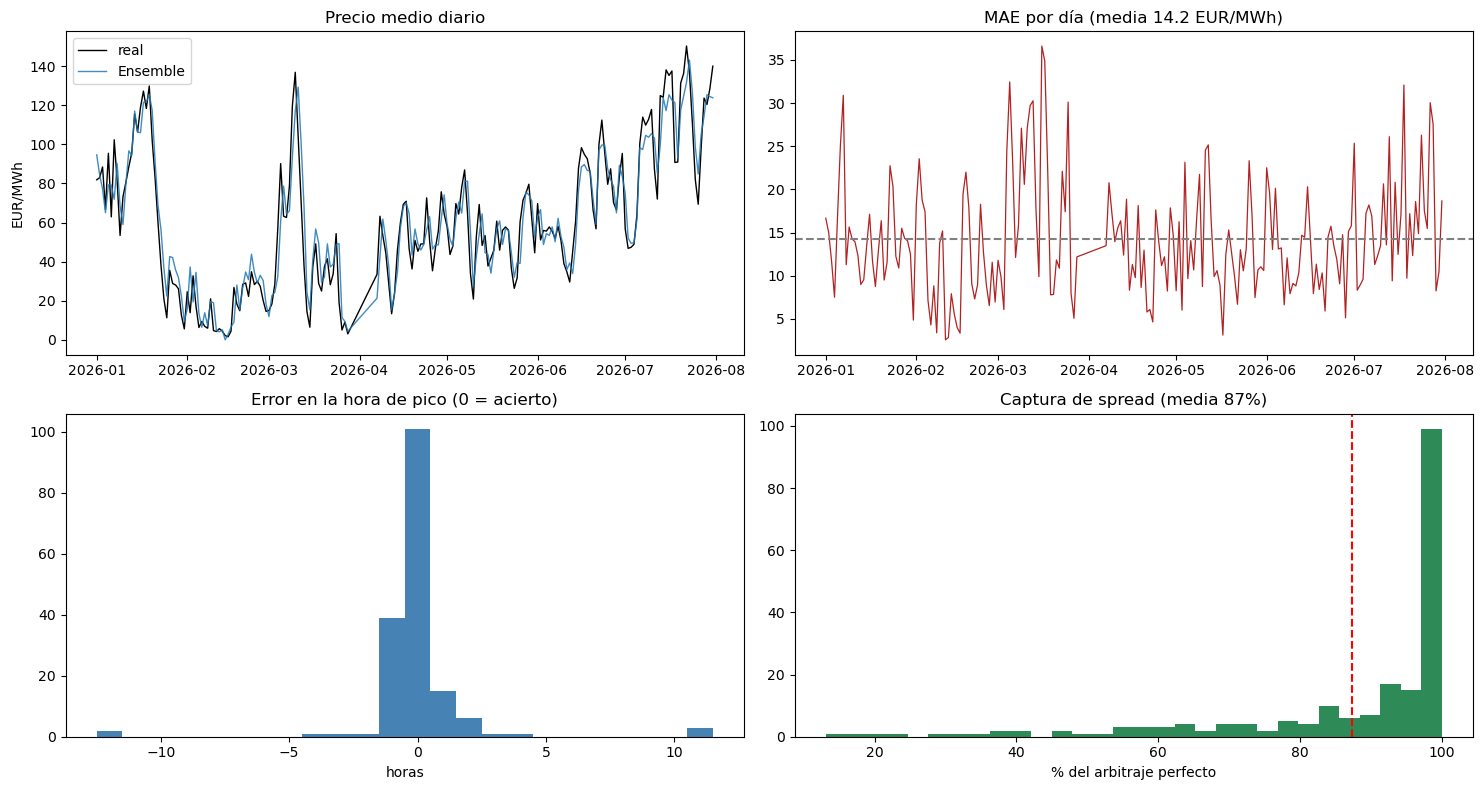

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(15, 8))

ax[0,0].plot(fm, yt.mean(1), color="black", lw=1, label="real")
ax[0,0].plot(fm, p.mean(1), lw=1, alpha=.85, label=mejor)
ax[0,0].set_title("Precio medio diario"); ax[0,0].set_ylabel("EUR/MWh"); ax[0,0].legend()

ax[0,1].plot(fm, diario.MAE_dia, lw=.9, color="firebrick")
ax[0,1].axhline(diario.MAE_dia.mean(), ls="--", color="grey")
ax[0,1].set_title(f"MAE por día (media {diario.MAE_dia.mean():.1f} EUR/MWh)")

ax[1,0].hist(h_max_p - h_max_r, bins=np.arange(-12, 13) - .5, color="steelblue")
ax[1,0].set_title("Error en la hora de pico (0 = acierto)"); ax[1,0].set_xlabel("horas")

ax[1,1].hist(diario.captura_pct, bins=30, color="seagreen")
ax[1,1].axvline(diario.captura_pct.mean(), color="r", ls="--")
ax[1,1].set_title(f"Captura de spread (media {diario.captura_pct.mean():.0f}%)")
ax[1,1].set_xlabel("% del arbitraje perfecto")

plt.tight_layout(); plt.show()

## 11. Lectura de resultados y siguientes pasos

**La referencia.** El naive D (repetir el precio de hoy) da **17,13 €/MWh de MAE** sobre test.
El sMAPE del 72% no indica un mal baseline: es alto porque el precio pasa cerca de cero en horas
de excedente solar y ahí cualquier error relativo se dispara. El MAE manda sobre el sMAPE.

**El hallazgo principal.** Predecir el **residuo frente al naive** en lugar del precio absoluto
es lo que separa "no bate al baseline" de "lo bate". En escala absoluta ningún modelo llegaba
(MLP 20,9 · LSTM 23,9 · Seq2Seq 27,2 frente a 17,1); con residuo, el Seq2Seq baja a 15,1. La
causa está diagnosticada: train incluye la crisis del gas de 2022 con una media de 93 €/MWh, y
la comprobación de escalado muestra que el nivel de test está medio sigma por debajo. Una red
regularizada tira hacia la media del target que ha visto; el naive es inmune porque no aprende
ningún nivel. **Al cambiar el target a la desviación, el problema de régimen desaparece.** Esto
es material de memoria, no un detalle de implementación.

**Método — el test se abre una vez.** Se itera contra validación (2025) y se reserva test (2026)
para el número final. Cada vez que se mira el test y se decide en función de lo que se ve, se
contamina; tras veinte iteraciones eligiendo "lo que va mejor en test", ese MAE ya no estima
nada. Las secciones 8b y 10 tienen una variable `MASCARA` / `M` justamente para trabajar sobre
validación mientras se itera.

**Si LightGBM gana al Seq2Seq, se reporta.** Con ~1.800 días y datos tabulares los árboles son
muy difíciles de batir. Decirlo con honestidad vale más que forzar el resultado contrario; el
deep learning tendrá su justificación cuando entre el tensor meteorológico, donde un árbol no
puede competir.

**Limitaciones a documentar.**

- Batería: ESIOS 2166/2167 no publican hasta el 20-nov-2024 y train acaba el 31-dic-2024, así
  que son constantes en casi todo el entrenamiento — de hecho la §3 las descarta por falta de
  varianza. No se puede modelar el efecto de la batería sobre el precio con estos datos, lo que
  refuerza el planteamiento del capítulo de optimización, donde es variable de decisión y no
  feature explicativa.
- Excepción ibérica (jun-2022 a dic-2023): entera dentro de train y fuera de validación y test.
  Desplazamiento de régimen por construcción, mitigado con el dummy, el residuo y el
  fine-tuning.
- Desde oct-2025 el precio horario es la media de cuatro MTU de 15 minutos distintos; la
  varianza intrahoraria se descarta.
- Ocho configuraciones de hiperparámetros y no más: con 357 días de validación, una búsqueda
  amplia sobreajustaría la propia validación.

**Siguiente iteración, por orden de retorno esperado.**

1. **Encoder con generación real hora a hora.** Ahora `X_enc` es solo precio, forma (168, 1). El
   `construir_tensores()` del script genera `X_hist` con 22 canales: generación por tecnología,
   demanda, flujos. Es el salto grande que queda y vale más que cualquier ajuste de dropout.
2. Ablaciones — sin previsiones, sin commodities, sin PDBC, con ERA5 perfecto. Cada una es un
   párrafo de la memoria con un número detrás. La de ERA5 cuantifica el valor de mejorar la
   previsión meteorológica y justifica el punto 4.
3. Atención sobre el decoder (patrón `BahdanauAttention` de `img2seq`): da los mapas del
   capítulo de interpretabilidad.
4. Tensor meteorológico ECMWF como entrada convolucional — el elemento diferencial del TFM y el
   único punto donde la GPU de Colab compensa de verdad.

## 12. Comparar variantes y ablación del encoder

Las dos tablas que van al capítulo. Ejecuta el notebook entero cambiando las constantes de la
celda 1 y anota el resultado aquí:

| Ejecución | `VARIANTE` | `ENCODER_MULTICANAL` | Qué mide |
|---|---|---|---|
| A | `sin_ntc_prev` | `True` | referencia |
| B | `sin_2020` | `True` | ¿compensa perder ~330 días por 6 columnas? |
| C | `sin_ntc_prev` | `False` | cuánto aporta el encoder multicanal |

**Compara en validación, no en test.** Aquí estás eligiendo entre alternativas, y cada vez que
se mira el test para decidir algo, se contamina.

Dato para interpretar B: `ree_ntc_impfr` y compañía llevan la misma capacidad de interconexión,
están en el decoder y tienen histórico completo desde 2020. Si `sin_2020` gana pese a entrenar
con menos días, significa que las dos series **no** son equivalentes, y eso merece comprobarse
directamente en la BD con la correlación entre ambas en el periodo donde coexisten.

In [ ]:
# Guarda el resultado de esta ejecucion para poder compararlo con las otras dos
import json as _json

reg = {"variante": VARIANTE, "encoder_multicanal": ENCODER_MULTICANAL,
       "canales": len(canales), "estaticos": int(Xs.shape[1]),
       "dias_train": int(tr.sum()), "dias_val": int(va.sum())}

# MAE en VALIDACION de cada modelo -- es lo correcto para elegir entre alternativas; el test
# se reserva para el numero final de la memoria
mae_val = {}
for nombre, modelo, entrada in [("MLP residuo", mlp_r, "plano"),
                                ("Seq2Seq residuo", s2r, "ent")]:
    try:
        p = (modelo.predict(plano[va], verbose=0) if entrada == "plano"
             else modelo.predict(ent(va), verbose=0))
        mae_val[nombre] = round(float(metricas(y[va], inv_r(p, va))["MAE"]), 2)
    except Exception as e:
        print(f"  ({nombre} no disponible: {e})")
mae_val["naive D"] = round(float(metricas(y[va], naive_todos[va])["MAE"]), 2)
reg["MAE_val"] = mae_val

etiqueta = f"{VARIANTE}_{'multi' if ENCODER_MULTICANAL else 'solo_precio'}"
Path(f"registro_{etiqueta}.json").write_text(_json.dumps(reg, indent=2), encoding="utf-8")
print(_json.dumps(reg, indent=2))

# tabla acumulada con todas las ejecuciones guardadas
regs = [ _json.loads(p.read_text(encoding="utf-8")) for p in sorted(Path(".").glob("registro_*.json")) ]
if len(regs) > 1:
    filas = []
    for r in regs:
        filas.append({"variante": r["variante"], "encoder": r["canales"],
                      "estaticos": r["estaticos"], "dias_train": r["dias_train"],
                      **r["MAE_val"]})
    display(pd.DataFrame(filas))

{
  "variante": "sin_ntc_prev",
  "encoder_multicanal": true,
  "canales": 22,
  "estaticos": 46,
  "dias_train": 1765,
  "dias_val": 339,
  "MAE_val": {
    "MLP residuo": 18.78,
    "Seq2Seq residuo": 17.23,
    "naive D": 20.28
  }
}
